# CS4403 Data Mining Project — Darknet Traffic Mining & Classification (CIC-Darknet2020)

## Project overview
This project uses **network flow data** to explore whether different types of internet traffic (especially **privacy-enhancing traffic like Tor and VPN**) show measurable statistical patterns.  
Each row in the dataset represents a **single network flow** (a summarized communication session), and each column contains a numeric feature describing that flow (e.g., packet counts, packet length statistics, timing/inter-arrival statistics, and active/idle behavior).

## Dataset
- **Name / Source:** CIC-Darknet2020 (Canadian Institute for Cybersecurity, University of New Brunswick)
- **Local file used in this notebook:** `Darknet.CSV`
- **Scale:** ~140k+ flow records and ~80+ features (exact counts printed after loading)
- **Labels (targets):**
  - `Label` → **Traffic type** (e.g., Tor / VPN / NonVPN / Non-Tor depending on the dataset version)
  - `Label.1` → **Application category** (e.g., Browsing, Chat, Audio-Streaming, File-Transfer, etc.)

## Project goals
### Goal 1 — Supervised learning (classification)
Build and compare machine learning models that can predict the **traffic type** (`Label`) from flow features.  
We evaluate models using metrics such as **accuracy, precision, recall, F1-score**, and a **confusion matrix** to understand where the model performs well or struggles.

### Goal 2 — Unsupervised learning (pattern discovery)
Explore whether flows naturally form groups using clustering (e.g., K-means / DBSCAN).  
This helps answer: *Do different traffic types form distinct clusters based only on their behavior features?*

### Goal 3 — Explainability and reliability
Because very high accuracy can sometimes happen due to shortcuts (e.g., hidden leakage, duplicates, or latent factors), we include checks to:
- test **overfitting risk** (train vs test gap, cross-validation)
- test for **data leakage / shortcuts** (dropping identifier-like columns)
- investigate **latent factors** (relationships between `Label` and `Label.1`, duplicates, and group-based splits if possible)
- explain what the model is using via **feature importance**

## What this notebook contains
1. Load dataset and summarize size/labels (required for reports)
2. Data cleaning and preprocessing
3. Exploratory Data Analysis (EDA)
4. Baseline supervised models + evaluation
5. Clustering exploration (optional section)
6. Robustness checks (overfitting / leakage / latent factors)
7. Feature importance + interpretation

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
)


from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    classification_report
)

pd.set_option('display.max_columns', 100)
%matplotlib inline

## 1) Setup + dataset download


In [14]:
import gdown

# Paste your Google Drive share link here (file link)
GDRIVE_URL = "https://drive.google.com/file/d/1dCmJ3NhCZ7QP_w3t5mdS04Lqg8n4MP5I/view?usp=drive_link"

# Download (fuzzy=True handles common Drive link formats)
# Output filename can be whatever you want
if GDRIVE_URL:
    gdown.download(GDRIVE_URL, output="Darknet.CSV", quiet=False, fuzzy=True)

DATA_PATH = "Darknet.CSV"
print("DATA_PATH =", DATA_PATH)

Downloading...
From: https://drive.google.com/uc?id=1dCmJ3NhCZ7QP_w3t5mdS04Lqg8n4MP5I
To: c:\Users\jaspi\Desktop\Winter 2026\CS4403\Project\CS4403-Project-main\CS4403-Project-main\Code\Darknet.CSV
100%|██████████| 66.3M/66.3M [00:01<00:00, 61.4MB/s]


DATA_PATH = Darknet.CSV


## 2) Load dataset + quick summary

Why: Your report needs the **format**, **#instances**, **#features**, and label breakdown.


In [15]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")], errors="ignore")

print("Format: CSV")
print("Rows, Columns =", df.shape)
df.head(3)

Format: CSV
Rows, Columns = (141531, 85)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label.1
0,10.152.152.11-216.58.220.99-57158-443-6,10.152.152.11,57158,216.58.220.99,443,6,24/07/2015 04:09:48 PM,229,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,8733.624454,229.0,0.0,229,229,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,4366.812227,4366.812227,0,0,0,0.0,0.0,2,0,0,0,2,0,0,0,1,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,1892,1047,0,20,0,0,0,0,0.0,0.0,0.0,0.0,Non-Tor,AUDIO-STREAMING
1,10.152.152.11-216.58.220.99-57159-443-6,10.152.152.11,57159,216.58.220.99,443,6,24/07/2015 04:09:48 PM,407,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,4914.004914,407.0,0.0,407,407,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,2457.002457,2457.002457,0,0,0,0.0,0.0,2,0,0,0,2,0,0,0,1,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,1987,1047,0,20,0,0,0,0,0.0,0.0,0.0,0.0,Non-Tor,AUDIO-STREAMING
2,10.152.152.11-216.58.220.99-57160-443-6,10.152.152.11,57160,216.58.220.99,443,6,24/07/2015 04:09:48 PM,431,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,4640.371230,431.0,0.0,431,431,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,2320.185615,2320.185615,0,0,0,0.0,0.0,2,0,0,0,2,0,0,0,1,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,2049,1047,0,20,0,0,0,0,0.0,0.0,0.0,0.0,Non-Tor,AUDIO-STREAMING


In [16]:
print("Columns:")
print(df.columns.tolist())

print("\nDtypes (count):")
print(df.dtypes.value_counts())

print("\nMissing values (total):", int(df.isna().sum().sum()))

Columns:
['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Fla

In [17]:
print(df['Label'].value_counts())

print("\n-----------------\n")

print(df['Label.1'].value_counts())

Label
Non-Tor        93356
NonVPN         23863
VPN            22919
Tor             1392
5494.505495        1
Name: count, dtype: int64

-----------------

Label.1
P2P                48520
Browsing           32808
Audio-Streaming    16580
Chat               11478
File-Transfer      11098
Video-Streaming     9486
Email               6145
VOIP                3566
AUDIO-STREAMING     1484
Video-streaming      281
File-transfer         84
0                      1
Name: count, dtype: int64


In [18]:
# Remove corrupted row in Label
df = df[df['Label'].isin(['Non-Tor','NonVPN','VPN','Tor'])]

# Standardize Label.1 values
df['Label.1'] = df['Label.1'].replace({
    'AUDIO-STREAMING':'Audio-Streaming',
    'Video-streaming':'Video-Streaming',
    'File-transfer':'File-Transfer'
})

# Remove invalid Label.1 row
df = df[df['Label.1'] != '0']

print(df['Label'].value_counts())

print("\n-----------------\n")

print(df['Label.1'].value_counts())

Label
Non-Tor    93356
NonVPN     23863
VPN        22919
Tor         1392
Name: count, dtype: int64

-----------------

Label.1
P2P                48520
Browsing           32808
Audio-Streaming    18064
Chat               11478
File-Transfer      11182
Video-Streaming     9767
Email               6145
VOIP                3566
Name: count, dtype: int64


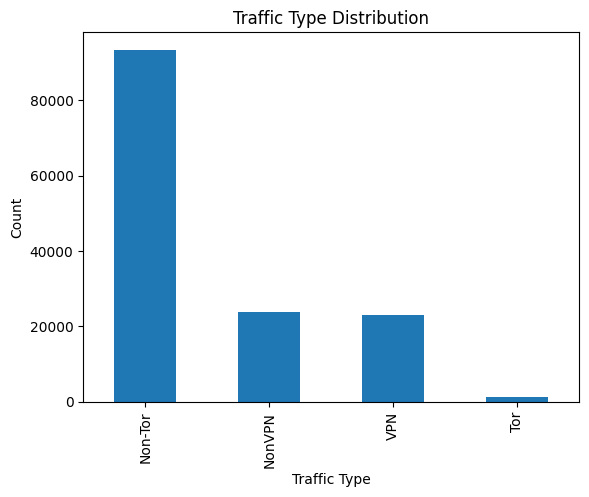

In [19]:
df['Label'].value_counts().plot(kind='bar')

plt.title('Traffic Type Distribution')
plt.xlabel('Traffic Type')
plt.ylabel('Count')

plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder


# Drop identifier columns
X = df.drop(columns=['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label', 'Label.1']).copy()

# Keep only numeric columns just in case
X = X.apply(pd.to_numeric, errors='coerce')

# Replace inf and -inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values
X = X.fillna(0)

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['Label'])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n")
print(classification_report(y_test, pred, target_names=le.classes_))

Accuracy: 0.9840316540662757

Classification Report:

              precision    recall  f1-score   support

     Non-Tor       1.00      1.00      1.00     18671
      NonVPN       0.95      0.96      0.95      4773
         Tor       0.98      0.90      0.94       278
         VPN       0.96      0.95      0.96      4584

    accuracy                           0.98     28306
   macro avg       0.97      0.95      0.96     28306
weighted avg       0.98      0.98      0.98     28306



In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# 1. Build feature matrix again from cleaned df
X = df.drop(columns=['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label', 'Label.1']).copy()

# 2. Force everything to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# 3. Replace inf values
X = X.replace([np.inf, -np.inf], np.nan)

# 4. Cap very large values just in case
X = X.clip(lower=-1e15, upper=1e15)

# 5. Fill missing values
X = X.fillna(0)

# 6. Final safety checks
print("Any NaN left:", X.isna().any().any())
print("Any +inf left:", np.isinf(X.to_numpy()).any())
print("Max value:", np.nanmax(X.to_numpy()))
print("Min value:", np.nanmin(X.to_numpy()))

# 7. Encode target
le = LabelEncoder()
y = le.fit_transform(df['Label'])

# 8. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 9. Train model
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 10. Predict
pred = model.predict(X_test)

# 11. Results
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n")
print(classification_report(y_test, pred, target_names=le.classes_))

Any NaN left: False
Any +inf left: False
Max value: 1000000000000000.0
Min value: -2255.0
Accuracy: 0.979898254786971

Classification Report:

              precision    recall  f1-score   support

     Non-Tor       1.00      1.00      1.00     18671
      NonVPN       0.94      0.95      0.94      4773
         Tor       0.95      0.86      0.91       278
         VPN       0.95      0.94      0.95      4584

    accuracy                           0.98     28306
   macro avg       0.96      0.94      0.95     28306
weighted avg       0.98      0.98      0.98     28306



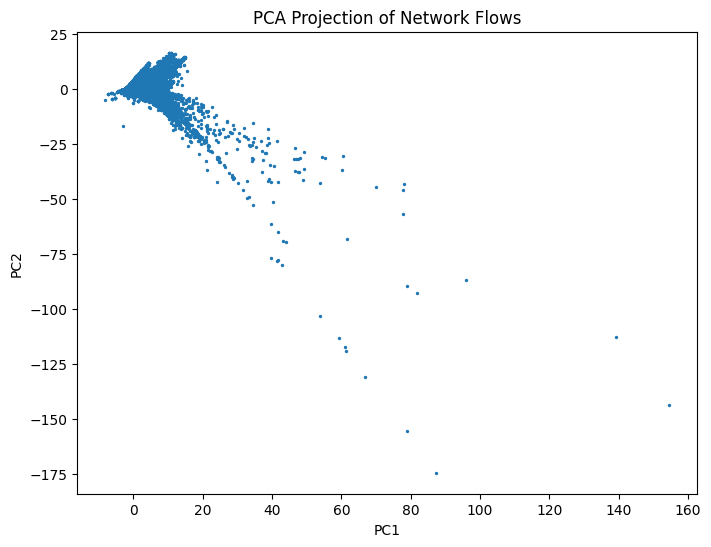

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=2)
plt.title("PCA Projection of Network Flows")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()